In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df= pd.read_csv(r"C:\CV\computer_vision_pima_diabetes\data\raw\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [69]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [70]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [71]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

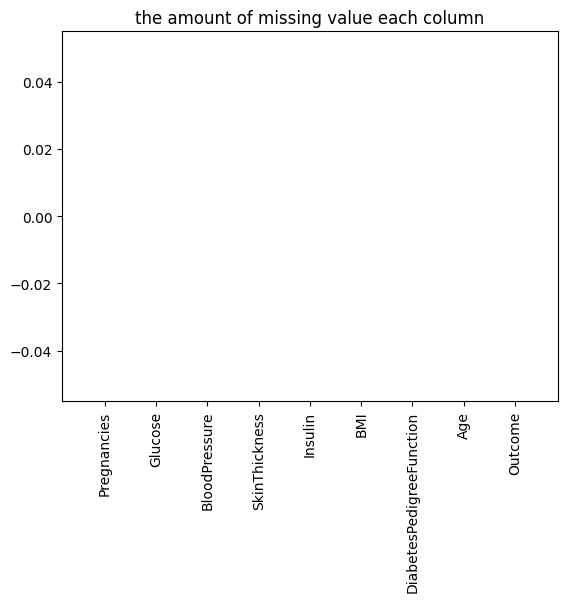

In [72]:

plt.bar(df.columns,df.isnull().sum().values,color='pink')
plt.xticks(rotation=90)
plt.title('the amount of missing value each column')
plt.show()

In [73]:
df.duplicated().sum()

np.int64(0)

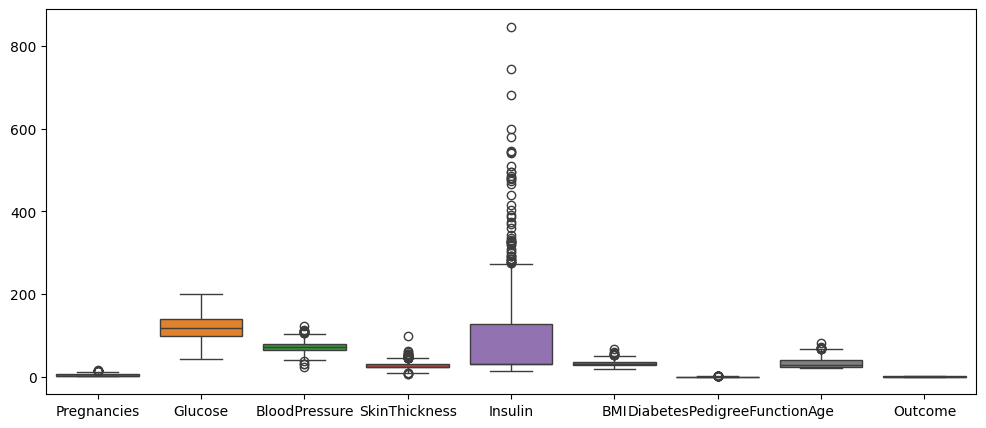

In [74]:
plt.figure(figsize=(12,5))
sns.boxplot(df)
plt.show()

In [75]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

In [76]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction','Age']

df_clean = remove_outliers(df, cols)

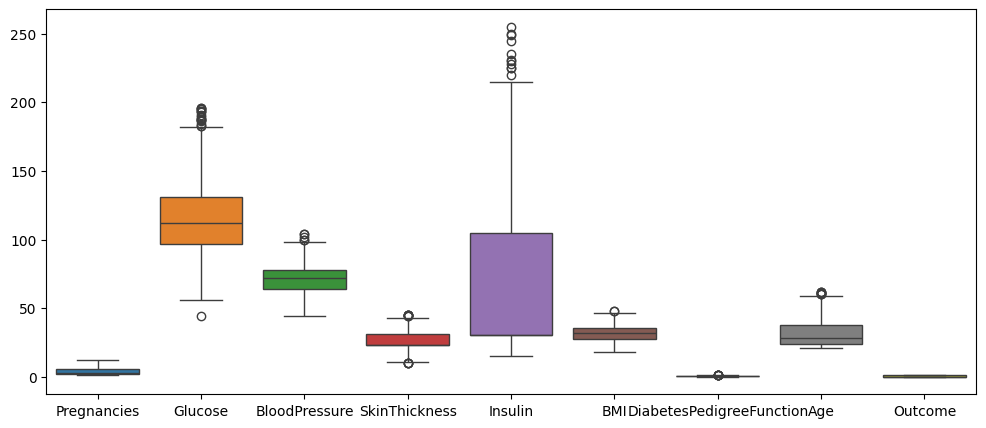

In [77]:
plt.figure(figsize=(12,5))
sns.boxplot(df_clean)
plt.show()

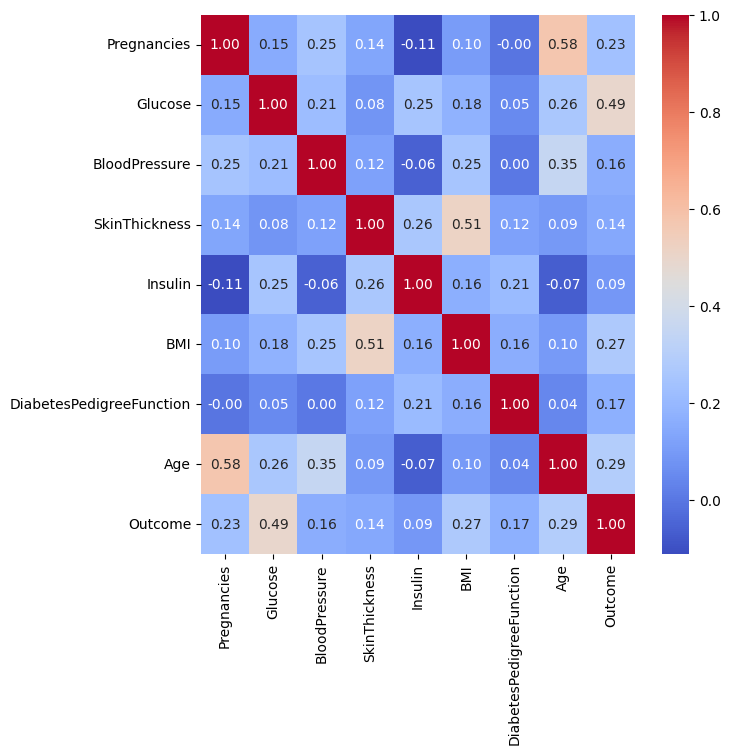

In [78]:


plt.figure(figsize=(7,7))
sns.heatmap(df_clean.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

In [79]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

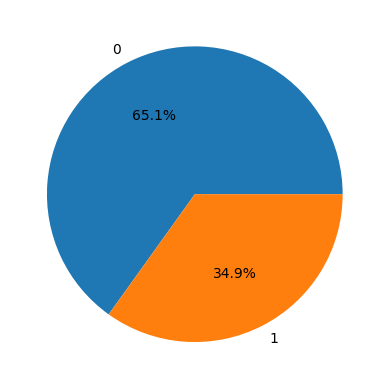

In [80]:
y.value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.show()

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [83]:
import numpy as np

np.save("C:\CV\computer_vision_pima_diabetes\data\processed\X_train.npy", X_train)
np.save("C:\CV\computer_vision_pima_diabetes\data\processed\X_test.npy", X_test)
np.save("C:\CV\computer_vision_pima_diabetes\data\processed\y_train.npy", y_train)
np.save("C:\CV\computer_vision_pima_diabetes\data\processed\y_test.npy", y_test)